# Notebook 06 — Leakage-Safe Temporal Model Selection

Protocol: **Selection Train (`release_year <= 2017`) → Validation (`2018`) → lock configuration → refit from scratch on Development (`<2019`) → Final Test (`>=2019`) exactly once**. Final-test performance cannot change the locked winner. Trong lần chạy Round 2 đã hiệu chỉnh, 2019+ không được dùng để chọn winner; tuy nhiên chính giai đoạn này đã được xem trong một vòng phát triển trước, nên không được hiểu là test set chưa từng được quan sát trong toàn bộ lịch sử dự án.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    for candidate in Path.cwd().resolve().parents:
        if (candidate / "src").exists() and (candidate / "5.DATA").exists():
            ROOT = candidate
            break
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

from datetime import datetime, timezone
import matplotlib.pyplot as plt

from src.evaluation import (
    DEVELOPMENT_SCOPE, EVALUATION_SCOPE_LABEL, FINAL_TEST_SCOPE,
    FIT_SCOPE_LABEL, SELECTION_TRAIN_SCOPE, VALIDATION_SCOPE,
    select_validation_winner, temporal_masks, write_winner_lock,
)
from src.features import (
    RAW_INPUT_FEATURES, SELECTED_ENGINEERED_FEATURES, TARGET,
    FeatureBuilder, get_model_features,
)
from src.modeling import (
    MODEL_NAMES, build_model_pipeline, grouped_feature_importance,
    regression_metric_variants, transformed_feature_importance,
)

DATA_PATH = ROOT / "5.DATA" / "processed" / "ml_ready_dataset.parquet"
ENGINEERED_PATH = ROOT / "5.DATA" / "processed" / "features_engineered.parquet"
EVAL_DIR = ROOT / "4.MODELS" / "4.2.evaluation"
MODEL_DIR = ROOT / "4.MODELS" / "hitradar_popularity"
for directory in (EVAL_DIR, MODEL_DIR): directory.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists() and ENGINEERED_PATH.exists(), "Run Notebook 05 first."

Project root: D:\Hitradar\hitradar-main


## 1. Partition validation and development parity

Trong lần chạy Round 2 đã hiệu chỉnh, labels 2019+ không được nạp vào biến chọn mô hình; trước khi lock chỉ hiển thị số dòng. Đây là phạm vi của bằng chứng lock trong Round 2, không phải khẳng định rằng giai đoạn 2019+ chưa từng được kiểm tra trong lịch sử dự án.

In [2]:
raw = pd.read_parquet(DATA_PATH)
saved = pd.read_parquet(ENGINEERED_PATH)
assert len(raw) == len(saved)
masks = temporal_masks(raw)

partition_rows = pd.DataFrame([
    {"Partition":"Selection Train", "Scope":SELECTION_TRAIN_SCOPE, "Rows":int(masks["selection_train"].sum())},
    {"Partition":"Validation", "Scope":VALIDATION_SCOPE, "Rows":int(masks["validation"].sum())},
    {"Partition":"Development", "Scope":DEVELOPMENT_SCOPE, "Rows":int(masks["development"].sum())},
    {"Partition":"Final Test", "Scope":FINAL_TEST_SCOPE, "Rows":int(masks["final_test"].sum())},
])
assert partition_rows.set_index("Partition").loc["Validation", "Rows"] >= 1000
display(partition_rows)

prelock_target_summary = pd.DataFrame({
    "Selection Train": raw.loc[masks["selection_train"], TARGET].describe(),
    "Validation 2018": raw.loc[masks["validation"], TARGET].describe(),
    "Development": raw.loc[masks["development"], TARGET].describe(),
}).T
display(prelock_target_summary)
print("Final Test target summary: deferred until after winner lock.")

X_selection = raw.loc[masks["selection_train"], RAW_INPUT_FEATURES]
y_selection = raw.loc[masks["selection_train"], TARGET]
X_validation = raw.loc[masks["validation"], RAW_INPUT_FEATURES]
y_validation = raw.loc[masks["validation"], TARGET]
X_development = raw.loc[masks["development"], RAW_INPUT_FEATURES]
y_development = raw.loc[masks["development"], TARGET]

parity_builder = FeatureBuilder(include_engineered=True).fit(X_development)
parity_index = raw.loc[masks["validation"]].sample(min(10_000, int(masks["validation"].sum())), random_state=1512).index
rebuilt = parity_builder.transform(raw.loc[parity_index, RAW_INPUT_FEATURES]).reset_index(drop=True)
expected = saved.loc[parity_index, rebuilt.columns].reset_index(drop=True)
numeric = rebuilt.select_dtypes(include=np.number).columns.tolist()
categorical = [c for c in rebuilt.columns if c not in numeric]
numeric_ok = bool(np.allclose(rebuilt[numeric], expected[numeric], rtol=1e-9, atol=1e-10, equal_nan=True))
categorical_ok = all(rebuilt[c].astype("string").equals(expected[c].astype("string")) for c in categorical)
parity_result = {"rows_checked":len(rebuilt), "fit_scope":DEVELOPMENT_SCOPE,
                 "numeric_allclose":numeric_ok, "categorical_exact":categorical_ok,
                 "status":"PASS" if numeric_ok and categorical_ok else "FAIL"}
assert parity_result["status"] == "PASS", parity_result
(EVAL_DIR / "feature_builder_saved_parity.json").write_text(json.dumps(parity_result, indent=2), encoding="utf-8")
print(parity_result)

,Partition,Scope,Rows
0,Selection Train,release_year <= 2017,543611
1,Validation,release_year == 2018,10936
2,Development,release_year < 2019,554547
3,Final Test,release_year >= 2019,32125


,count,mean,std,min,25%,50%,75%,max
Selection Train,543611.0,26.370013,17.355282,0.0,12.0,26.0,39.0,90.0
Validation 2018,10936.0,42.139539,21.789451,0.0,33.0,48.0,57.0,89.0
Development,554547.0,26.680997,17.590774,0.0,12.0,26.0,39.0,90.0


Final Test target summary: deferred until after winner lock.


{'rows_checked': 10000, 'fit_scope': 'release_year < 2019', 'numeric_allclose': True, 'categorical_exact': True, 'status': 'PASS'}


## 2. Phase A — fit nine candidates on Selection Train; evaluate only Validation 2018

All category encoders, imputers, scalers, FeatureBuilder statistics, and estimators are fit only on selection-train rows. Both raw and deployed clipped metrics are retained.

In [3]:
experiments = [
    {"Experiment":"Baseline With-Time", "include_engineered":False, "include_time":True},
    {"Experiment":"Engineered With-Time", "include_engineered":True, "include_time":True},
    {"Experiment":"Engineered No-Time", "include_engineered":True, "include_time":False},
]
selection_rows = []
for experiment in experiments:
    declared = get_model_features(include_engineered=experiment["include_engineered"], include_time=experiment["include_time"])
    for model_name in MODEL_NAMES:
        print("Selection fit:", experiment["Experiment"], "/", model_name)
        candidate = build_model_pipeline(model_name, include_engineered=experiment["include_engineered"], include_time=experiment["include_time"])
        candidate.fit(X_selection, y_selection)
        assert candidate.named_steps["features"].fit_row_count_ == len(X_selection)
        validation_pred_raw = candidate.predict(X_validation)
        for variant, metric in regression_metric_variants(y_validation, validation_pred_raw).items():
            selection_rows.append({
                "Experiment":experiment["Experiment"], "Model":model_name,
                "Prediction Variant":variant, "Feature Count":len(declared), **metric,
                "Fit Scope":FIT_SCOPE_LABEL, "Evaluation Scope":EVALUATION_SCOPE_LABEL,
            })
selection_metrics = pd.DataFrame(selection_rows).sort_values(
    ["Prediction Variant", "RMSE", "MAE", "Experiment", "Model"], kind="mergesort"
).reset_index(drop=True)
SELECTION_METRICS_PATH = EVAL_DIR / "model_selection_validation_metrics.csv"
selection_metrics.to_csv(SELECTION_METRICS_PATH, index=False)
display(selection_metrics)

Selection fit: Baseline With-Time / Linear Regression


Selection fit: Baseline With-Time / Random Forest


Selection fit: Baseline With-Time / XGBoost


Selection fit: Engineered With-Time / Linear Regression


Selection fit: Engineered With-Time / Random Forest


Selection fit: Engineered With-Time / XGBoost


Selection fit: Engineered No-Time / Linear Regression


Selection fit: Engineered No-Time / Random Forest


Selection fit: Engineered No-Time / XGBoost


,Experiment,Model,Prediction Variant,Feature Count,MAE,RMSE,R2,Fit Scope,Evaluation Scope
0,Engineered With-Time,XGBoost,"Clipped [0,100]",32,12.600405,16.597462,0.419729,selection train,validation 2018
1,Baseline With-Time,XGBoost,"Clipped [0,100]",18,12.670252,16.682617,0.413760,selection train,validation 2018
2,Engineered With-Time,Random Forest,"Clipped [0,100]",32,12.741017,16.704076,0.412251,selection train,validation 2018
3,Baseline With-Time,Random Forest,"Clipped [0,100]",18,12.835459,16.855803,0.401525,selection train,validation 2018
4,Engineered With-Time,Linear Regression,"Clipped [0,100]",32,16.205409,19.793129,0.174768,selection train,validation 2018
5,Engineered No-Time,XGBoost,"Clipped [0,100]",26,16.687436,20.061089,0.152273,selection train,validation 2018
6,Baseline With-Time,Linear Regression,"Clipped [0,100]",18,16.670608,20.437123,0.120195,selection train,validation 2018
7,Engineered No-Time,Random Forest,"Clipped [0,100]",26,17.051373,20.452718,0.118851,selection train,validation 2018
8,Engineered No-Time,Linear Regression,"Clipped [0,100]",26,19.312845,22.525811,-0.068828,selection train,validation 2018
9,Engineered With-Time,XGBoost,Raw,32,12.619090,16.601459,0.419450,selection train,validation 2018


## 3. Lock winner from validation only

The winner is the minimum clipped validation RMSE, then MAE, then deterministic lexical tie-break. The lock is written before final-test labels or predictions are accessed.

In [4]:
winner_row = select_validation_winner(selection_metrics)
winner_experiment = next(e for e in experiments if e["Experiment"] == winner_row["Experiment"])
WINNER_LOCK_PATH = MODEL_DIR / "selection_winner_lock.json"
winner_lock = write_winner_lock(
    WINNER_LOCK_PATH, winner=winner_row,
    validation_metrics_path=SELECTION_METRICS_PATH,
    include_engineered=winner_experiment["include_engineered"],
    include_time=winner_experiment["include_time"],
)
assert winner_lock["final_test_labels_observed"] is False
print("LOCKED WINNER:", winner_lock["selection_winner_experiment"], "/", winner_lock["selection_winner_model"])
display(winner_row.to_frame().T)

clipped_validation = selection_metrics.query("`Prediction Variant` == 'Clipped [0,100]'")
time_bias_rows = []
for model_name in MODEL_NAMES:
    with_time = clipped_validation.query("Model == @model_name and Experiment == 'Engineered With-Time'").iloc[0]
    no_time = clipped_validation.query("Model == @model_name and Experiment == 'Engineered No-Time'").iloc[0]
    delta = float(no_time.RMSE - with_time.RMSE)
    time_bias_rows.append({"Model":model_name, "Evaluation Scope":EVALUATION_SCOPE_LABEL,
        "With-Time RMSE":float(with_time.RMSE), "No-Time RMSE":float(no_time.RMSE),
        "No-Time minus With-Time RMSE":delta,
        "Interpretation":"positive means time features improved validation RMSE" if delta > 0 else "non-positive means no-time was equal/better"})
time_bias_table = pd.DataFrame(time_bias_rows)
time_bias_table.to_csv(EVAL_DIR / "validation_time_bias_comparison.csv", index=False)
display(time_bias_table)

LOCKED WINNER: Engineered With-Time / XGBoost


,Experiment,Model,Prediction Variant,Feature Count,MAE,RMSE,R2,Fit Scope,Evaluation Scope
0,Engineered With-Time,XGBoost,"Clipped [0,100]",32,12.600405,16.597462,0.419729,selection train,validation 2018


,Model,Evaluation Scope,With-Time RMSE,No-Time RMSE,No-Time minus With-Time RMSE,Interpretation
0,Linear Regression,validation 2018,19.793129,22.525811,2.732682,positive means time features improved validati...
1,Random Forest,validation 2018,16.704076,20.452718,3.748642,positive means time features improved validati...
2,XGBoost,validation 2018,16.597462,20.061089,3.463627,positive means time features improved validati...


## 4. Phase B — refit the locked configuration from scratch on all Development rows

Nothing fitted during Phase A is reused. Feature medians, thresholds, decade statistics, imputer, scaler, encoder, and estimator are all refit on `release_year < 2019`.

In [5]:
final_pipeline = build_model_pipeline(
    winner_lock["selection_winner_model"],
    include_engineered=winner_lock["include_engineered"],
    include_time=winner_lock["include_time"],
)
final_pipeline.fit(X_development, y_development)
assert final_pipeline.named_steps["features"].fit_row_count_ == len(X_development)
final_model_path = MODEL_DIR / "popularity_pipeline.joblib"
joblib.dump(final_pipeline, final_model_path, compress=3)
print(f"Final refit rows: {len(X_development):,}; scope: {DEVELOPMENT_SCOPE}")

Final refit rows: 554,547; scope: release_year < 2019


## 5. Phase C — evaluate Final Test exactly once after lock and refit

The locked winner is not reconsidered after these results. Raw metrics describe direct model output; clipped metrics match deployed API behavior.

Final Test target distribution (first observed after lock):


,count,mean,std,min,25%,50%,75%,max
target_popularity,32125.0,42.917074,23.925773,0.0,29.0,50.0,60.0,100.0


,MAE,RMSE,R2
Raw,16.212926,20.598066,0.258802
"Clipped [0,100]",16.201599,20.594952,0.259026


,Popularity Group,Rows,MAE,RMSE,Bias (Actual-Prediction),Bias Direction
0,Low 0-29,8155,27.048092,30.961213,-25.439388,overprediction
1,Emerging 30-49,7760,7.767721,10.190787,-1.817599,overprediction
2,Medium 50-69,13122,11.923011,14.061268,11.662668,underprediction
3,High 70-100,3088,26.932610,27.925723,26.932610,underprediction


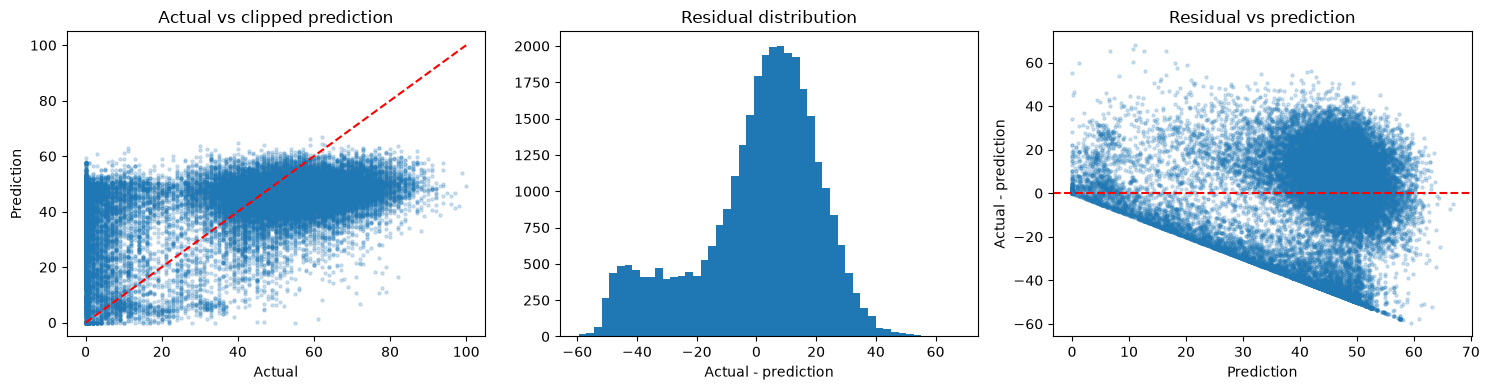

In [6]:
assert WINNER_LOCK_PATH.exists() and final_model_path.exists()
X_final_test = raw.loc[masks["final_test"], RAW_INPUT_FEATURES]
y_final_test = raw.loc[masks["final_test"], TARGET]
print("Final Test target distribution (first observed after lock):")
display(y_final_test.describe().to_frame().T)

final_pred_raw = final_pipeline.predict(X_final_test)  # the one final-test prediction call
final_test_evaluation_count = 1
final_pred_clipped = np.clip(final_pred_raw, 0, 100)
metric_variants = regression_metric_variants(y_final_test, final_pred_raw)
display(pd.DataFrame(metric_variants).T)

diagnostics = pd.DataFrame({"Actual":np.asarray(y_final_test), "Prediction Raw":final_pred_raw,
                            "Prediction Clipped":final_pred_clipped})
diagnostics["Residual (Actual-Prediction)"] = diagnostics["Actual"] - diagnostics["Prediction Clipped"]
diagnostics["Popularity Group"] = pd.cut(diagnostics["Actual"], [-np.inf,29,49,69,np.inf],
    labels=["Low 0-29","Emerging 30-49","Medium 50-69","High 70-100"])

def group_metrics(group):
    residual = group["Residual (Actual-Prediction)"].to_numpy()
    bias = residual.mean()
    return pd.Series({"Rows":len(group), "MAE":np.abs(residual).mean(),
        "RMSE":np.sqrt(np.mean(residual**2)), "Bias (Actual-Prediction)":bias,
        "Bias Direction":"underprediction" if bias > 0 else "overprediction" if bias < 0 else "neutral"})

error_groups = diagnostics.groupby("Popularity Group", observed=True).apply(group_metrics, include_groups=False).reset_index()
display(error_groups)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(diagnostics["Actual"], diagnostics["Prediction Clipped"], s=5, alpha=.2)
axes[0].plot([0,100],[0,100], color="red", ls="--"); axes[0].set(title="Actual vs clipped prediction", xlabel="Actual", ylabel="Prediction")
axes[1].hist(diagnostics["Residual (Actual-Prediction)"], bins=50); axes[1].set(title="Residual distribution", xlabel="Actual - prediction")
axes[2].scatter(diagnostics["Prediction Clipped"], diagnostics["Residual (Actual-Prediction)"], s=5, alpha=.2)
axes[2].axhline(0, color="red", ls="--"); axes[2].set(title="Residual vs prediction", xlabel="Prediction", ylabel="Actual - prediction")
plt.tight_layout(); fig.savefig(EVAL_DIR / "final_test_diagnostics.png", dpi=140, bbox_inches="tight"); plt.show()

## 6. Save canonical artifacts and reload parity

Feature importance is descriptive of the locked, development-fitted model; it is not causal evidence.

In [7]:
detailed_importance = transformed_feature_importance(final_pipeline)
grouped_importance = grouped_feature_importance(final_pipeline)
display(detailed_importance.head(25)); display(grouped_importance.head(25))

error_groups.to_csv(EVAL_DIR / "final_error_groups.csv", index=False)
detailed_importance.to_csv(EVAL_DIR / "final_transformed_feature_importance.csv", index=False)
grouped_importance.to_csv(EVAL_DIR / "final_grouped_feature_importance.csv", index=False)
pd.DataFrame({"track_id":raw.loc[masks["final_test"], "track_id"].astype(str).values,
              "actual":np.asarray(y_final_test), "prediction_raw":final_pred_raw,
              "prediction_clipped":final_pred_clipped}).to_parquet(EVAL_DIR / "final_test_predictions.parquet", index=False)
partition_rows.to_csv(EVAL_DIR / "temporal_partition_rows.csv", index=False)

final_contract_features = get_model_features(
    include_engineered=winner_lock["include_engineered"], include_time=winner_lock["include_time"]
)
final_metrics = {
    "selection_protocol":winner_lock["selection_protocol"],
    "selection_winner_experiment":winner_lock["selection_winner_experiment"],
    "selection_winner_model":winner_lock["selection_winner_model"],
    "winner_locked_at_utc":winner_lock["locked_at_utc"],
    "winner_locked_before_final_test":True,
    "include_engineered":winner_lock["include_engineered"],
    "include_time":winner_lock["include_time"],
    "model_features":final_contract_features,
    "selected_engineered_features":SELECTED_ENGINEERED_FEATURES,
    "final_refit_scope":DEVELOPMENT_SCOPE,
    "final_refit_rows":len(X_development),
    "feature_builder_fit_rows":final_pipeline.named_steps["features"].fit_row_count_,
    "final_test_scope":FINAL_TEST_SCOPE,
    "final_test_rows":len(X_final_test),
    "final_test_evaluation_count":final_test_evaluation_count,
    "final_test_evaluated_at_utc":datetime.now(timezone.utc).isoformat(),
    "raw_test_metrics":metric_variants["Raw"],
    "clipped_test_metrics":metric_variants["Clipped [0,100]"],
    "deployed_prediction_variant":"Clipped [0,100]",
    "residual_convention":"actual - prediction; positive means underprediction",
    "feature_parity":parity_result,
    "validation_metrics_artifact":SELECTION_METRICS_PATH.name,
    "winner_lock_artifact":WINNER_LOCK_PATH.name,
}
FINAL_METRICS_PATH = MODEL_DIR / "final_test_metrics.json"
FINAL_METRICS_PATH.write_text(json.dumps(final_metrics, indent=2), encoding="utf-8")

reloaded_pipeline = joblib.load(final_model_path)
reload_probe = X_final_test.head(20)
reload_ok = bool(np.allclose(reloaded_pipeline.predict(reload_probe), final_pipeline.predict(reload_probe)))
reload_result = {"rows_checked":len(reload_probe), "prediction_allclose":reload_ok, "status":"PASS" if reload_ok else "FAIL"}
assert reload_ok
(EVAL_DIR / "pipeline_reload_parity.json").write_text(json.dumps(reload_result, indent=2), encoding="utf-8")
print(json.dumps(final_metrics, indent=2))
print("Winner remains locked regardless of final-test performance.")

,Feature,Importance
0,release_year,0.141084
1,decade_1950,0.094406
2,decade_2000,0.092596
3,decade_1940,0.065406
4,decade_2010,0.060777
5,release_month_12.0,0.051726
6,decade_1990,0.039883
7,explicit,0.039306
8,decade_1930,0.036349
9,acousticness,0.031957


,Feature Group,Importance
0,decade,0.421368
1,release_year,0.141084
2,release_month,0.097346
3,explicit,0.039306
4,key,0.034104
5,acousticness,0.031957
6,duration_category,0.029732
7,instrumentalness,0.026195
8,release_precision,0.021152
9,tempo_category,0.019546


{
  "selection_protocol": "fit release_year <= 2017; evaluate release_year == 2018; minimum clipped validation RMSE, MAE then stable lexical tie-break",
  "selection_winner_experiment": "Engineered With-Time",
  "selection_winner_model": "XGBoost",
  "winner_locked_at_utc": "2026-08-13T15:56:51.716773+00:00",
  "winner_locked_before_final_test": true,
  "include_engineered": true,
  "include_time": true,
  "model_features": [
    "duration_min",
    "release_year",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "explicit",
    "mode",
    "release_month",
    "decade",
    "release_precision",
    "key",
    "time_signature",
    "key_sin",
    "key_cos",
    "dance_energy",
    "positive_energy",
    "acoustic_energy_balance",
    "dance_valence",
    "acoustic_instrumental",
    "tempo_energy",
    "energy_vs_period_avg",
    "dance_vs_period_avg",
    "energy_loudness",


## 7. Conclusion

The selection table contains validation-2018 evidence only. The final pipeline configuration equals the persisted lock, was refit on all pre-2019 development data, and then evaluated on the 2019+ horizon without changing the winner. The corrected Round-2 pipeline did not use that horizon for winner selection; however, the same horizon had been inspected during an earlier development iteration, so it is not a historically never-observed test set.